In [36]:
from typing import List, TypedDict,Literal
from pydantic import BaseModel,Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import  StateGraph, START,END
from dotenv import load_dotenv

load_dotenv()

True

In [37]:
docs = (
    PyPDFLoader("documents/Company_Policies.pdf").load()
    + PyPDFLoader("documents/Company_Profile.pdf").load()
    + PyPDFLoader("documents/Product_and_Pricing.pdf").load()
)

#### Chunking

In [38]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=150).split_documents(docs)

### Embedding and Retriever

In [39]:
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')
vector_store = FAISS.from_documents(chunks,embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k":1})

#### LLM

In [40]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

## Graph State

In [41]:
class State(TypedDict):

    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs : List[Document]
    context :str
    answer :str

    issup : Literal["fully_supported","partially_supported","no_support"]

    evidence: List[str]

    retries: int

### Decide Retrieval

In [42]:
class RetrieveDecision(BaseModel):

    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human","Question: {question}")
    ]
)

decide_retrieval_chain = decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision)


def decide_retrieval(state:State):
    out = decide_retrieval_chain.invoke({'question':state['question']})

    return {"need_retrieval": out.should_retrieve}

### Generate Direct Node

In [43]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your knowledge"
        ),
        ("human","{question}")
    ]
)

def generate_direct(state: State):

    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state['question']
        )
    )

    return {"answer": out.content}

### Retriever

In [44]:
def retrieve(state: State):
    return {'docs': retriever.invoke(state['question'])}

### Is Relevant Node

In [45]:
class RelevanceDecision(BaseModel):
    is_relevant : bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

is_relevant_chain = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):

    relevant_docs : List[Document] = []

    for doc in state['docs']:

        out = is_relevant_chain.invoke({'question':state['question'],'document':doc.page_content})

        if out.is_relevant:
            relevant_docs.append(doc)

    return {'relevant_docs':relevant_docs}

### Generate From context

In [46]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG Assistant\n"
            "Answer the user question using only the provided context"
        ),
        (
            "human",
            "Question:\n{question}\n"
            "Context:\n{context}"
        ),
    ]
)

def generate_from_context(state: State):

    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.","context":""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state['question'],
            context=context
        )
    )

    return {"answer": out.content,"context":context}

### No relevant Docs

In [47]:
def no_relevant_docs(state: State):
    return  {"answer": "No relevant document found.","context":""}

### Route 1

In [48]:
def route_after_decide(state: State):

    if state['need_retrieval']:
        return 'retrieve'
    return 'generate_direct'

### Route 2

In [49]:
def route_after_relevance(state: State):
    if state.get('relevant_docs') and len(state['relevant_docs']) > 0:
        return 'generate_from_context'
    return "no_relevant_docs"

## Is Supported and Loop

In [50]:
class IsSuPDecision(BaseModel):
    issup: Literal["fully_supported","partially_supported","no_support"]
    evidence : List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Check if ANSWER is supported by CONTEXT.\n"
            "Return JSON: issup (fully_supported | partially_supported | no_support), evidence.\n\n"
            "- fully_supported: all claims directly in CONTEXT, no added wording.\n"
            "- partially_supported: facts match but includes any added interpretation/qualitative words.\n"
            "- no_support: key claims unsupported.\n\n"
            "Rules: be strict; any added wording ⇒ partially_supported; mostly unsupported ⇒ no_support; evidence ≤3 exact quotes; no outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        )
    ]
)

issup_chain = issup_prompt | llm.with_structured_output(IsSuPDecision)

def is_sup(state: State):
    out = issup_chain.invoke({"question":state['question'],"answer":state.get("answer",""),"context":state.get("context","")})

    return {"issup": out.issup,"evidence":out.evidence}

In [51]:
MAX_RETRIES = 2

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

### Accept the answer

In [52]:
def accept_answer(state: State):
    return {}  # keep answer as-is

### Revise Answer Node 

In [53]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

### Graph build

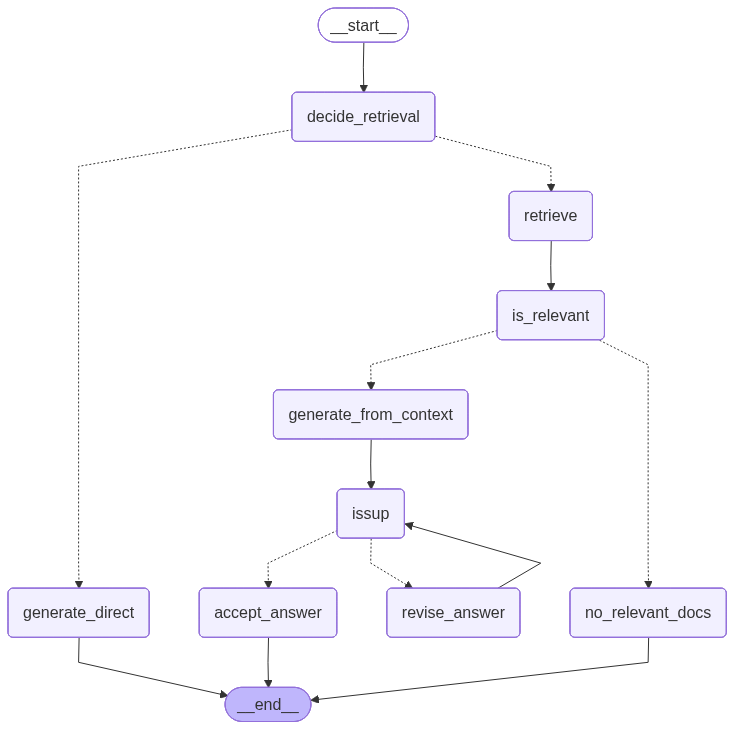

In [54]:
g = StateGraph(State)

g.add_node("decide_retrieval",decide_retrieval)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)
g.add_node("is_relevant",is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_relevant_docs",no_relevant_docs)
g.add_node("issup",is_sup)

g.add_node("revise_answer",revise_answer)
g.add_node("accept_answer",accept_answer)


g.add_edge(START,'decide_retrieval')

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve"
    }
)


g.add_edge("generate_direct",END)

g.add_edge("retrieve","is_relevant")
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context":"generate_from_context",
        "no_relevant_docs":"no_relevant_docs"

    }
)

g.add_edge("no_relevant_docs",END)
g.add_edge("generate_from_context","issup")
g.add_conditional_edges(
    "issup",
    route_after_issup,
    {"accept_answer":"accept_answer","revise_answer":"revise_answer"}
    )

g.add_edge("revise_answer","issup")
g.add_edge("accept_answer",END)

app = g.compile()

app

In [55]:
result = app.invoke(
    {
        "question": "Describe NexaAI’s company culture.",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": [],
        "retries": 0,
    },
    config={"recursion_limit": 80},  # ✅ bump limit
)



print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 1
#relevant_docs: 1
issup: fully_supported
evidence: ['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'All employment decisions are made without discrimination.', 'Equal opportunity employer', 'Bi-annual performance reviews', 'Clear career progression framework', 'Strict anti-harassment policy', 'Employees are encouraged to maintain a healthy work-life balance.', 'Annual Leave: 18 working days per year', 'Sick Leave: 10 working days per year']
answer: NexaAI is committed to a fair, inclusive, and performance-driven workplace. They are an equal opportunity employer, meaning all employment decisions are made without discrimination. The company has bi-annual performance reviews and a clear career progression framework. NexaAI also has a strict anti-harassment policy and encourages employees to maintain a healthy work-life balance, offering 18 working days of annual leave and 10 working days of sick leave per year.


In [56]:
print(result.get("retries"))

0
